In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

In [2]:
os.chdir('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/')
print(os.getcwd())

/Users/cherylxiang/Documents/GitHub/demultiplexing-methods


In [3]:
#load runtimes
methods = ['demultiplex', 'demultiplex2', 'htodemux', 'hashsolo', 'hasheddrops',
           'bffraw', 'bffcluster', 'gmmdemux', 'demuxmix', 'demuxmixnaive', 'beacon']

datasets = [
    'mcginnis_ms',
    'mcginnis_ab',
    'bar11',
    'gaublomme',
    'howitt_batch1_c1',
    'howitt_batch1_c2',
    'howitt_batch2_c1',
    'howitt_batch2_c2',
    'howitt_batch3_c1',
    'howitt_batch3_c2',
    'howitt_capture1',
    'howitt_capture2',
    'howitt_capture3',
]

runtime_files = glob.glob('results/*/*/runtime.csv')

all_runtimes = []
for f in runtime_files:
    df = pd.read_csv(f)
    all_runtimes.append(df)

runtimes_df = pd.concat(all_runtimes, ignore_index=True)
runtimes_df = runtimes_df[runtimes_df['dataset'].isin(datasets)]

print(f'Total runtime records: {len(runtimes_df)}')
runtimes_df.head()


Total runtime records: 134


,dataset,method,runtime_seconds
0,bar11,cmddemux,6.453
1,howitt_batch3_c2,cmddemux,264.747
2,howitt_batch2_c2,cmddemux,336.448
3,howitt_batch1_c1,cmddemux,37.453
4,howitt_capture1,cmddemux,51.190


In [4]:
#summary stats by method
method_stats = runtimes_df.groupby('method')['runtime_seconds'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2).reset_index()
method_stats.columns = ['method', 'mean', 'median', 'std', 'min', 'max']
method_stats = method_stats.sort_values('mean')
print('Runtime summary by method (seconds):')

method_stats

Runtime summary by method (seconds):


,method,mean,median,std,min,max
9,hashsolo,0.08,0.08,0.06,0.02,0.20
7,demuxmixnaive,0.97,0.88,0.63,0.21,2.18
10,htodemux,1.20,1.10,0.72,0.30,2.38
8,gmmdemux,2.44,2.40,0.30,2.07,2.94
6,demuxmix,12.53,13.32,5.19,6.13,17.34
4,demultiplex,20.99,11.16,26.46,2.15,95.53
1,bff_cluster,24.81,19.50,11.64,12.61,45.94
2,bff_raw,24.81,19.50,11.64,12.61,45.94
0,beacon,29.43,28.90,19.94,4.22,66.35
5,demultiplex2,29.68,26.90,13.85,8.80,51.99


In [5]:
#summary stats by dataset
dataset_stats = runtimes_df.groupby('dataset')['runtime_seconds'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2).reset_index()
dataset_stats.columns = ['dataset', 'mean', 'median', 'std', 'min', 'max']
dataset_stats = dataset_stats.sort_values('mean')
print('Runtime summary by dataset (seconds):')
dataset_stats

Runtime summary by dataset (seconds):


,dataset,mean,median,std,min,max
1,gaublomme,4.60,2.15,4.79,0.03,12.61
12,mcginnis_ms,7.27,6.13,6.39,0.04,16.92
11,mcginnis_ab,8.84,8.02,7.14,0.04,17.34
0,bar11,9.60,8.00,8.02,0.08,19.50
2,howitt_batch1_c1,14.11,14.75,12.90,0.08,37.45
9,howitt_capture2,14.33,10.96,15.42,0.02,44.96
10,howitt_capture3,14.63,14.75,14.04,0.02,38.48
3,howitt_batch1_c2,15.12,16.40,13.96,0.08,40.99
8,howitt_capture1,16.15,11.37,17.77,0.02,51.19
4,howitt_batch2_c1,37.13,28.37,55.51,0.14,186.38


In [6]:
pivot = runtimes_df.pivot_table(
    index='method',
    columns='dataset',
    values='runtime_seconds'
).round(2)

pivot

dataset,bar11,gaublomme,howitt_batch1_c1,howitt_batch1_c2,howitt_batch2_c1,howitt_batch2_c2,howitt_batch3_c1,howitt_batch3_c2,howitt_capture1,howitt_capture2,howitt_capture3,mcginnis_ab,mcginnis_ms
method,,,,,,,,,,,,,
beacon,14.71,4.22,18.33,21.18,43.94,47.42,66.35,57.40,36.09,29.88,28.90,8.02,6.13
bff_cluster,19.50,12.61,22.57,23.50,37.24,39.46,40.71,45.94,17.75,16.04,16.19,15.69,15.33
bff_raw,19.50,12.61,22.57,23.50,37.24,39.46,40.71,45.94,17.75,16.04,16.19,15.69,15.33
cmddemux,6.45,1.41,37.45,40.99,186.38,336.45,580.84,264.75,51.19,44.96,38.48,13.12,7.40
demultiplex,8.00,2.15,11.16,11.63,19.50,48.98,95.53,39.77,5.00,5.88,13.30,7.36,4.57
demultiplex2,17.57,8.80,24.46,25.79,41.16,44.36,51.99,51.88,29.43,26.90,29.87,16.74,16.92
demuxmix,16.10,6.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.34,10.55
demuxmixnaive,0.52,0.21,1.00,1.03,1.26,1.53,2.18,2.05,0.88,0.61,0.42,0.57,0.34
gmmdemux,2.62,2.12,2.40,2.40,2.66,2.74,2.49,2.81,2.09,2.07,2.09,2.25,2.94


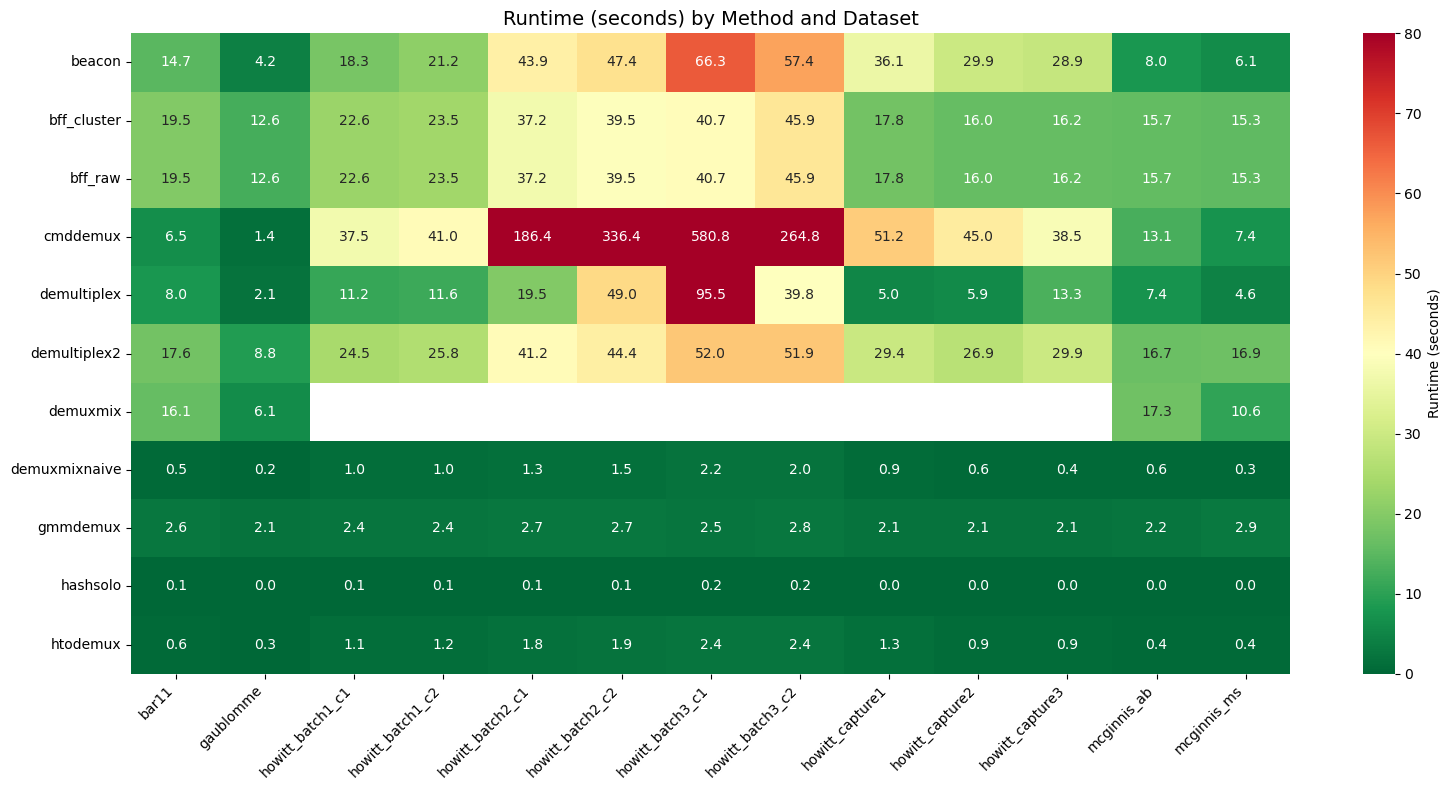

In [7]:
#heatmap
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, cbar_kws={'label': 'Runtime (seconds)'}, vmin = 0, vmax = 80)
ax.set_title('Runtime (seconds) by Method and Dataset', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('analysis/figures/runtime_heatmap.pdf')
plt.show()

/var/folders/5j/gy3kvrts21bg9h0mjxn2bwww0000gn/T/ipykernel_23294/1803558510.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(method_order,


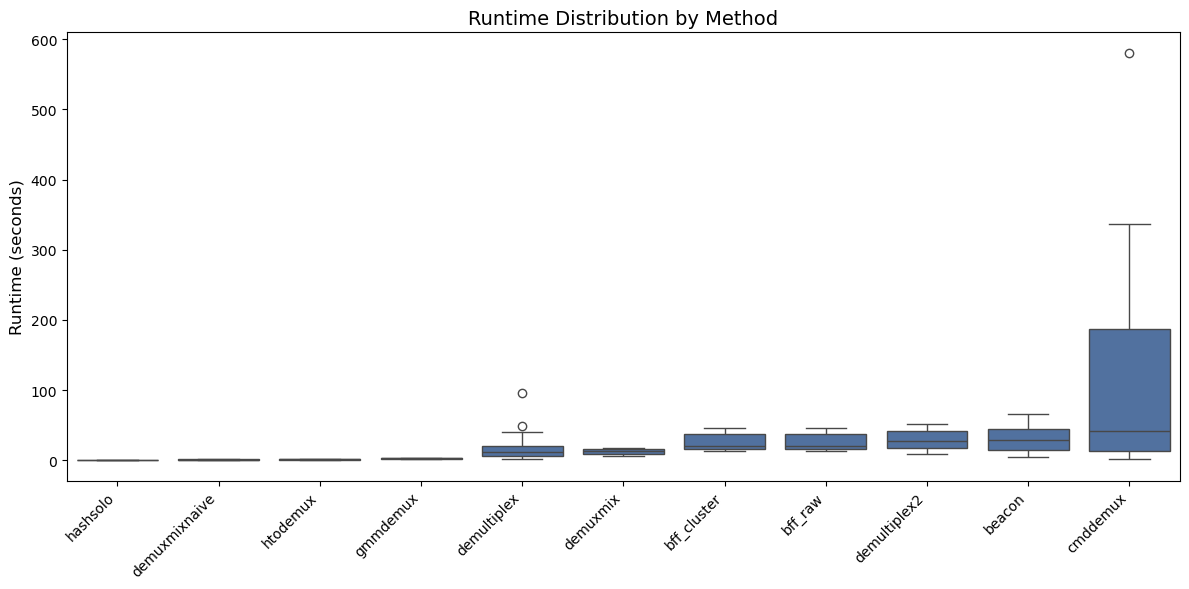

In [8]:
#boxplots
method_order = sorted(runtimes_df['method'].unique(),
                      key=lambda m: runtimes_df[runtimes_df['method']==m]['runtime_seconds'].median())

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=runtimes_df, x='method', y='runtime_seconds',
            order=method_order, ax=ax, color='#446fac')
ax.set_xticklabels(method_order,
                   rotation=45, ha='right')
ax.set_xlabel('')
ax.set_ylabel('Runtime (seconds)', fontsize=12)
ax.set_title('Runtime Distribution by Method', fontsize=14)
plt.tight_layout()
plt.savefig('analysis/figures/runtime_boxplot.pdf')
plt.show()

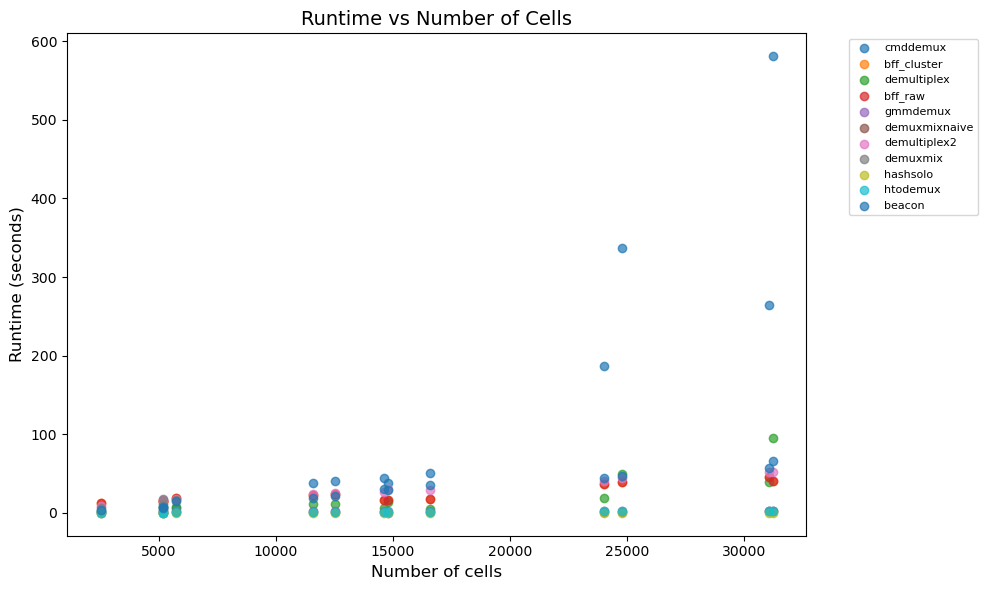

In [11]:
#scatterplot (runtime vs n_cells)

# load cell counts from summary csvs
cell_counts = []
for method in methods:
    files = glob.glob(f'results/{method}/*/summary.csv')
    for f in files:
        dataset_id = f.split('/')[2]
        df = pd.read_csv(f)
        total = df[df['classification'] == 'total']['n'].values
        if len(total) > 0:
            cell_counts.append({'dataset': dataset_id, 'n_cells': total[0]})

cell_counts_df = pd.DataFrame(cell_counts).drop_duplicates('dataset')

# merge with runtimes
scatter_df = runtimes_df.merge(cell_counts_df, on='dataset')

fig, ax = plt.subplots(figsize=(10, 6))
for method in scatter_df['method'].unique():
    subset = scatter_df[scatter_df['method'] == method]
    ax.scatter(subset['n_cells'], subset['runtime_seconds'],
               label=method, alpha=0.7)

ax.set_xlabel('Number of cells', fontsize=12)
ax.set_ylabel('Runtime (seconds)', fontsize=12)
ax.set_title('Runtime vs Number of Cells', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('analysis/figures/runtime_vs_ncells.pdf')
plt.show()